# Emotion Classification 
- with RNNs, LSTMs and GRUs

### classifying text into 6 emotions (sadness ,joy love, anger, fear, surprise)

### Import Libraries


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#this library help to import dataset from  hugging face

from datasets import load_dataset

### 2 Load data set

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')

In [3]:
train_text=emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text=emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [4]:
label_names = emotion_dataset['train'].features['label'].names


In [11]:
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})

df_test = pd.DataFrame({
    'text': test_text,
    'label': [label_names[i] for i in test_label]
})

In [6]:
print(df_train.head())

                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [7]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

# EDA (Exploratory Data Analysis)

<Axes: xlabel='label', ylabel='count'>

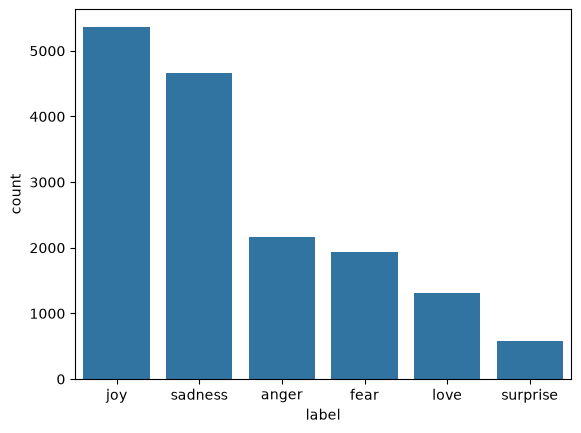

In [8]:
sns.countplot(x = 'label', data= df_train, order= df_train['label'].value_counts().index)

# Data Preprocessing - Using NLP
- tokenize text, pad sequences to max length 50, and convert labels into numpy array

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train['text']) #what it does it ..... "I love u" in this text each works is given rank

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen= 50, padding='post', truncating= 'post') #this is train X
padded_test_sequence = pad_sequences(test_sequence, maxlen= 50, padding='post', truncating= 'post')   # this is test X

train_labels = np.array(train_label) # this is train Y
test_labels = np.array(test_label)   # this is test Y
num_classes = len(np.unique(train_labels))

6

In [21]:
print(f"Vocabulary Size:{len(tokenizer.word_index)}")
print(f"Max Sentences Length: {padded_train_sequence.shape[1]}")

Vocabulary Size:15213
Max Sentences Length: 50


# Shared Training Utilities
- compute class weight mannually


In [22]:
from sklearn.utils import class_weight

In [24]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes= np.unique(train_labels),
    y= train_labels
)


In [27]:
class_weight_dict = dict(enumerate(class_weights))

- now apply early stoping

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)